IMPORT REQUIRED LIBRARIES

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import math
import warnings
warnings.filterwarnings('ignore')

# ML libraries - Estimators
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier, MultiOutputRegressor
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

# Preprocessing & Model Selection
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)



✓ All imports successful


 Set Paths and Load Dataset

In [139]:
# Set paths
REPO_ROOT = Path('e:\\SmartPaddyAdvisor')
DATA_PATH = REPO_ROOT / 'data' / 'SriLanka_Paddy_ML_Dataset_Enhanced.csv'
MODEL_FOLDER = REPO_ROOT / 'backend' / 'model'
EDA_FOLDER = MODEL_FOLDER / 'eda'

MODEL_FOLDER.mkdir(parents=True, exist_ok=True)
EDA_FOLDER.mkdir(parents=True, exist_ok=True)

print(f'Repository root: {REPO_ROOT}')
print(f'Data path: {DATA_PATH}')
print(f'Model folder: {MODEL_FOLDER}')
print(f'EDA folder: {EDA_FOLDER}')

Repository root: e:\SmartPaddyAdvisor
Data path: e:\SmartPaddyAdvisor\data\SriLanka_Paddy_ML_Dataset_Enhanced.csv
Model folder: e:\SmartPaddyAdvisor\backend\model
EDA folder: e:\SmartPaddyAdvisor\backend\model\eda


 Load Dataset

In [140]:
# Load dataset
df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nFirst few rows:')
df.head()

Raw shape: (2000, 30)
Columns: ['FieldID', 'Region', 'FieldArea_ha', 'Soil_pH', 'Temperature_C', 'Humidity_%', 'Rainfall_mm', 'PloughDepth_cm', 'PloughMethod', 'SoilAdjustment_kgLime', 'IrrigationAdvice', 'SeedAmount_kg', 'PlantSpacing_cm', 'Fertilizer_Basal_Urea_kg', 'Fertilizer_Basal_TSP_kg', 'Fertilizer_Basal_MOP_kg', 'WaterManagementAdvice_Stage4', 'TillerIncreaseTip', 'Fertilizer_2ndDose_Urea_kg', 'Fertilizer_2ndDose_TSP_kg', 'Fertilizer_2ndDose_MOP_kg', 'WaterControlAdvice_Stage5', 'WaterControlAdvice_Stage6', 'PesticideSuggestion', 'HumidityTarget_%', 'WaterLevelAdvice_Stage7', 'PredictedYield_kg_ha', 'HarvestingDate', 'FinalMoisture_%', 'PostHarvestAdvice']

First few rows:


,FieldID,Region,FieldArea_ha,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,PloughDepth_cm,PloughMethod,SoilAdjustment_kgLime,...,Fertilizer_2ndDose_MOP_kg,WaterControlAdvice_Stage5,WaterControlAdvice_Stage6,PesticideSuggestion,HumidityTarget_%,WaterLevelAdvice_Stage7,PredictedYield_kg_ha,HarvestingDate,FinalMoisture_%,PostHarvestAdvice
0,1,Intermediate Low,1.79,3.57,31.1,75.3,2448.8,15,Chisel,537,...,42.96,Flood for 1 week,Reduce water pre-flowering,Chlorpyrifos,86.2,Maintain 3-5cm,4792.3,2026-02-23,14.2,Thresh immediately
1,2,Dry Low,1.02,5.55,31.3,76.4,873.4,17,Mouldboard,571,...,24.48,Flood for 1 week,Ensure moist soil,Fipronil,83.3,Shallow water 3 days,5390.9,2026-02-20,14.3,Sun-dry 3 days
2,3,Intermediate Low,4.26,4.41,31.6,85.2,2314.9,13,Rotavator,785,...,102.24,Maintain 5cm water,Maintain shallow flooding,Chlorpyrifos,84.7,Maintain 3-5cm,4777.1,2026-02-21,14.8,Thresh immediately
3,4,Intermediate Low,3.83,6.08,29.6,76.1,1697.1,14,Rotavator,412,...,91.92,Maintain 5cm water,Reduce water pre-flowering,NaN,87.4,Alternate wetting,4897.4,2026-02-28,14.5,Thresh immediately
4,5,Dry Low,3.92,4.20,29.5,79.8,2488.0,12,Mouldboard,567,...,94.08,Flood for 1 week,Maintain shallow flooding,Fipronil,88.7,Alternate wetting,4475.1,2026-02-24,15.8,Sun-dry 3 days


In [141]:
df.dtypes

FieldID                           int64
Region                           object
FieldArea_ha                    float64
Soil_pH                         float64
Temperature_C                   float64
Humidity_%                      float64
Rainfall_mm                     float64
PloughDepth_cm                    int64
PloughMethod                     object
SoilAdjustment_kgLime             int64
IrrigationAdvice                 object
SeedAmount_kg                   float64
PlantSpacing_cm                   int64
Fertilizer_Basal_Urea_kg        float64
Fertilizer_Basal_TSP_kg         float64
Fertilizer_Basal_MOP_kg         float64
WaterManagementAdvice_Stage4     object
TillerIncreaseTip                object
Fertilizer_2ndDose_Urea_kg      float64
Fertilizer_2ndDose_TSP_kg       float64
Fertilizer_2ndDose_MOP_kg       float64
WaterControlAdvice_Stage5        object
WaterControlAdvice_Stage6        object
PesticideSuggestion              object
HumidityTarget_%                float64


 Data Cleaning & Preprocessing

In [142]:
# Define columns
feature_cols = ['Temperature_C', 'Soil_pH', 'Rainfall_mm', 'FieldArea_ha', 'Humidity_%']
numeric_targets = [
    'PredictedYield_kg_ha',
    'PloughDepth_cm',
    'SoilAdjustment_kgLime',
    'SeedAmount_kg',
    'PlantSpacing_cm',
    'Fertilizer_Basal_Urea_kg',
    'Fertilizer_Basal_TSP_kg',
    'Fertilizer_Basal_MOP_kg',
    'Fertilizer_2ndDose_Urea_kg',
    'Fertilizer_2ndDose_TSP_kg',
    'Fertilizer_2ndDose_MOP_kg'
]
text_targets = [
    'PloughMethod',
    'IrrigationAdvice',
    'WaterManagementAdvice_Stage4',
    'TillerIncreaseTip',
    'WaterControlAdvice_Stage5',
    'WaterControlAdvice_Stage6',
    'PesticideSuggestion',
    'PostHarvestAdvice'
]

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'Numeric targets ({len(numeric_targets)}): {numeric_targets}')
print(f'Text targets ({len(text_targets)}): {text_targets}')

Feature columns (5): ['Temperature_C', 'Soil_pH', 'Rainfall_mm', 'FieldArea_ha', 'Humidity_%']
Numeric targets (11): ['PredictedYield_kg_ha', 'PloughDepth_cm', 'SoilAdjustment_kgLime', 'SeedAmount_kg', 'PlantSpacing_cm', 'Fertilizer_Basal_Urea_kg', 'Fertilizer_Basal_TSP_kg', 'Fertilizer_Basal_MOP_kg', 'Fertilizer_2ndDose_Urea_kg', 'Fertilizer_2ndDose_TSP_kg', 'Fertilizer_2ndDose_MOP_kg']
Text targets (8): ['PloughMethod', 'IrrigationAdvice', 'WaterManagementAdvice_Stage4', 'TillerIncreaseTip', 'WaterControlAdvice_Stage5', 'WaterControlAdvice_Stage6', 'PesticideSuggestion', 'PostHarvestAdvice']


Handling null values

In [143]:
# Drop rows missing required columns
needed_cols = feature_cols + numeric_targets + text_targets
df_clean = df.dropna(subset=needed_cols).copy()
print(f'After dropping NA rows: {df_clean.shape} (removed {df.shape[0] - df_clean.shape[0]} rows)')

# Convert numeric columns
for c in feature_cols + numeric_targets:
    df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

print('Converted numeric columns')

After dropping NA rows: (1350, 30) (removed 650 rows)
Converted numeric columns


fill nul values 

In [144]:
# Impute missing feature values with median
print('\nMissing values before imputation:')
print(df_clean[feature_cols].isnull().sum())

df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].median())

print('\nMissing values after imputation:')
print(df_clean[feature_cols].isnull().sum())


Missing values before imputation:
Temperature_C    0
Soil_pH          0
Rainfall_mm      0
FieldArea_ha     0
Humidity_%       0
dtype: int64

Missing values after imputation:
Temperature_C    0
Soil_pH          0
Rainfall_mm      0
FieldArea_ha     0
Humidity_%       0
dtype: int64


Outlier handling 

In [145]:
# Outlier detection and capping (IQR method)
def detect_outliers_iqr(series):
    """Detect outliers using IQR method"""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return (series < low) | (series > high)

def cap_outliers(series):
    """Cap outliers using IQR method"""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return series.clip(lower=low, upper=high)

# Apply capping
for c in feature_cols:
    outlier_count = detect_outliers_iqr(df_clean[c]).sum()
    if outlier_count > 0:
        df_clean[c] = cap_outliers(df_clean[c])
        print(f'{c}: detected and capped {outlier_count} outliers')

print('\nCleaned data summary:')
df_clean[feature_cols].describe()


Cleaned data summary:


,Temperature_C,Soil_pH,Rainfall_mm,FieldArea_ha,Humidity_%
count,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000
mean,29.426148,5.510896,1655.827630,3.001585,82.748370
std,1.442839,1.157493,486.914887,1.148741,4.411068
min,27.000000,3.500000,801.900000,1.000000,75.000000
25%,28.200000,4.502500,1251.350000,1.970000,79.100000
50%,29.400000,5.570000,1656.700000,3.055000,82.800000
75%,30.600000,6.500000,2069.650000,3.980000,86.700000
max,32.000000,7.490000,2499.500000,5.000000,90.000000


 Exploratory Data Analysis (EDA)

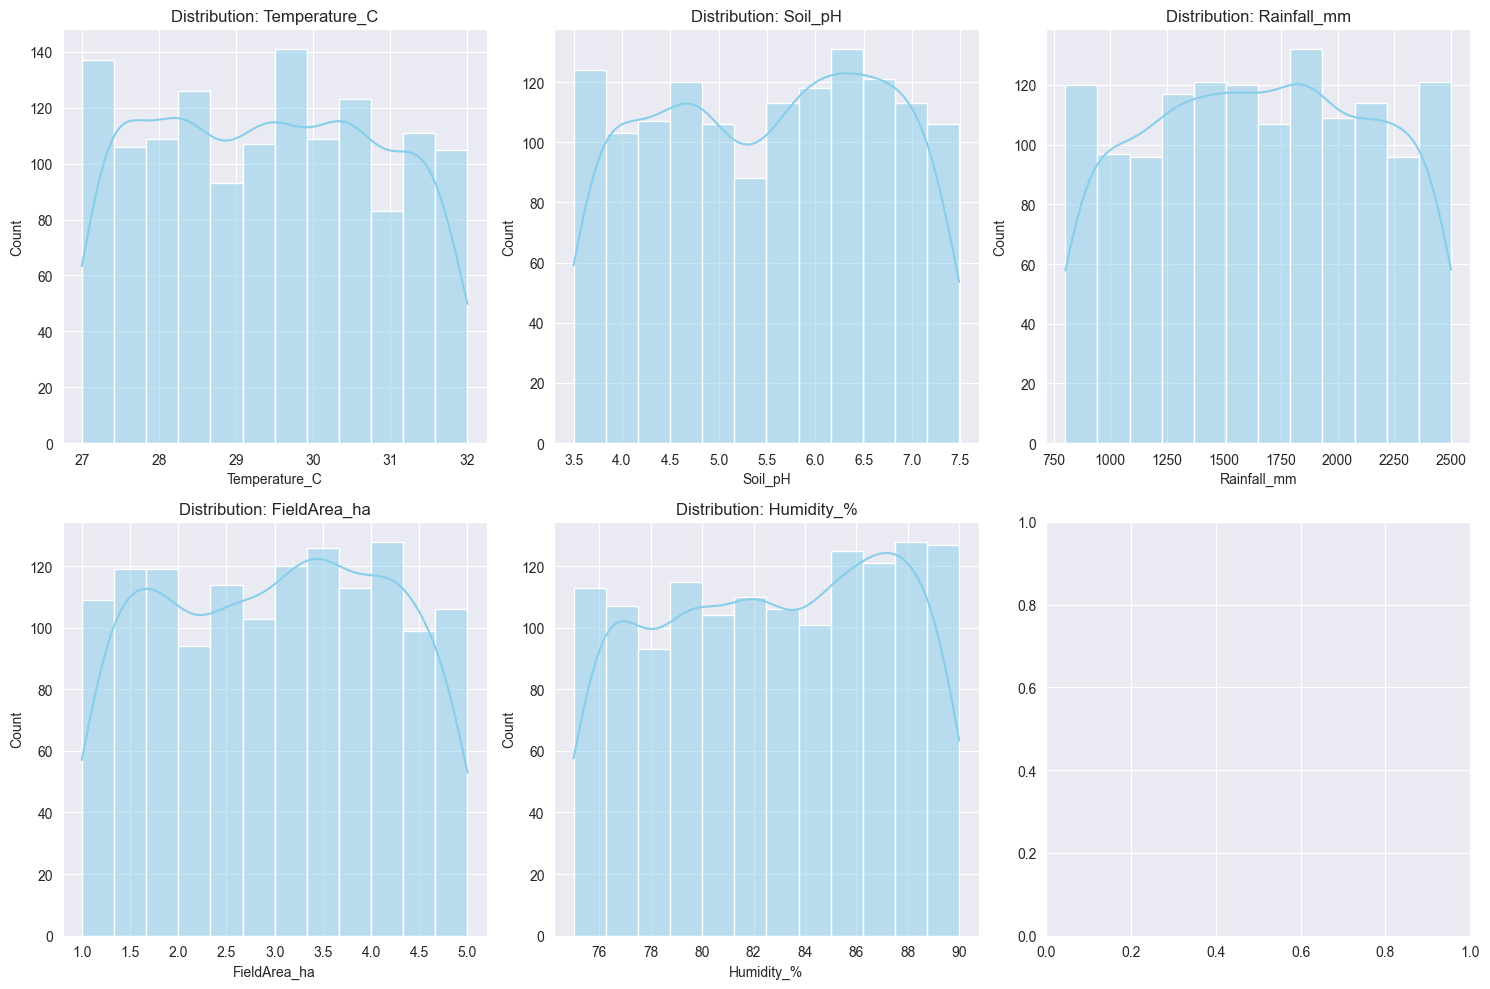

Saved: feature_distributions.png


In [146]:
# Feature distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution: {col}')

plt.tight_layout()
plt.savefig(EDA_FOLDER / 'feature_distributions.png', dpi=100)
plt.show()
print('Saved: feature_distributions.png')

Heat mapping

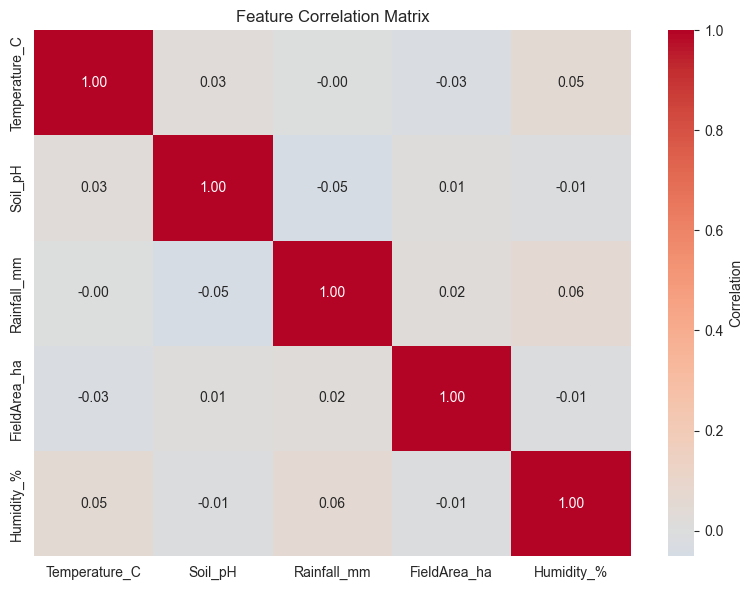

Saved: correlation_matrix.png


In [147]:
# Correlation matrix
corr_matrix = df_clean[feature_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(EDA_FOLDER / 'correlation_matrix.png', dpi=100)
plt.show()
print('Saved: correlation_matrix.png')

In [148]:
# Save feature summary to CSV
summary = df_clean[feature_cols].describe().T
summary.to_csv(EDA_FOLDER / 'feature_summary.csv')
print('Saved: feature_summary.csv')
summary

Saved: feature_summary.csv


,count,mean,std,min,25%,50%,75%,max
Temperature_C,1350.0,29.426148,1.442839,27.0,28.2000,29.400,30.60,32.00
Soil_pH,1350.0,5.510896,1.157493,3.5,4.5025,5.570,6.50,7.49
Rainfall_mm,1350.0,1655.827630,486.914887,801.9,1251.3500,1656.700,2069.65,2499.50
FieldArea_ha,1350.0,3.001585,1.148741,1.0,1.9700,3.055,3.98,5.00
Humidity_%,1350.0,82.748370,4.411068,75.0,79.1000,82.800,86.70,90.00


polot diagram for category features

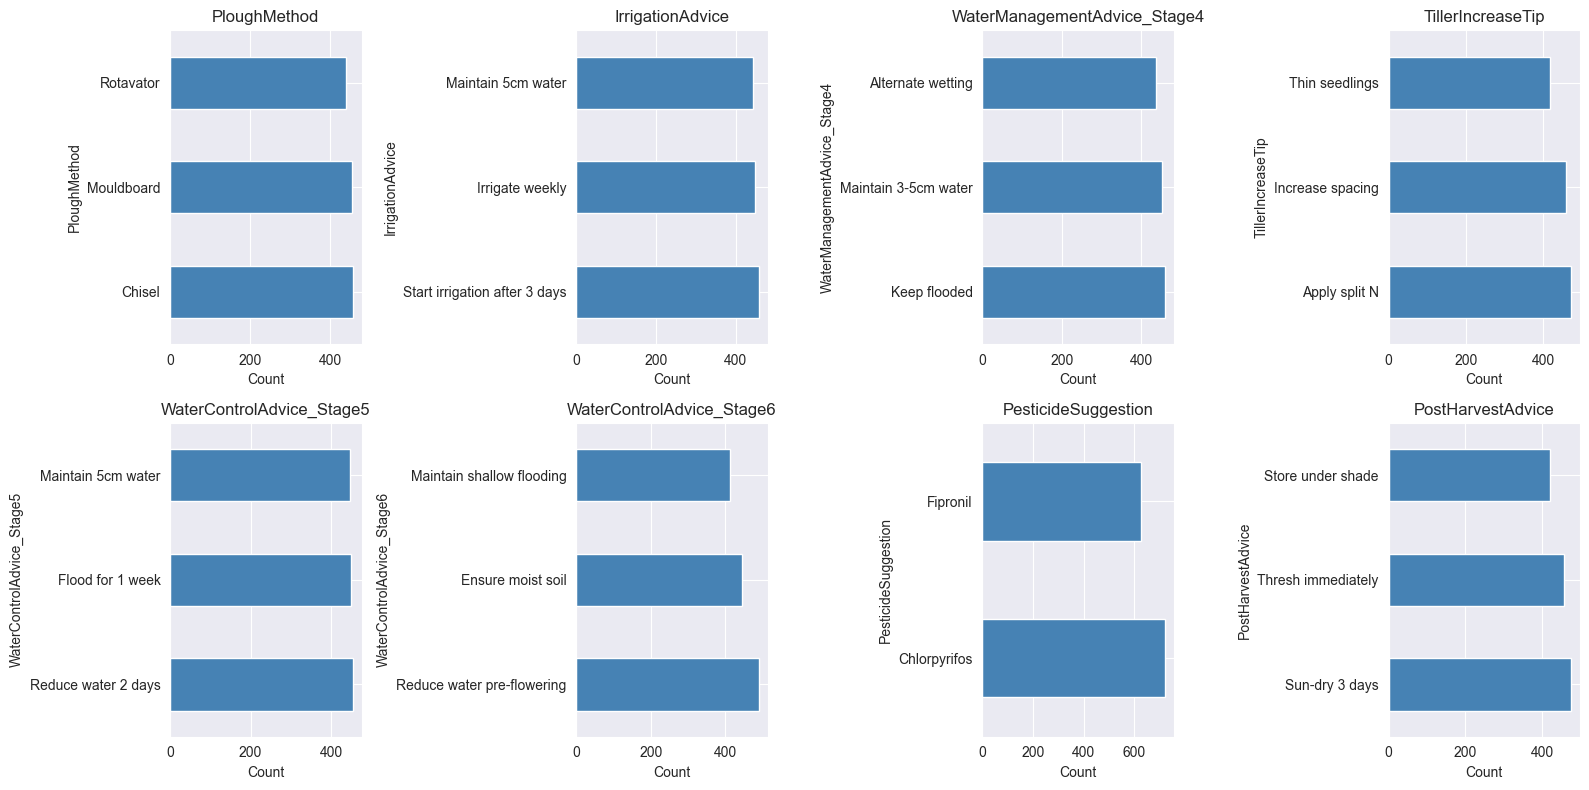

Saved: text_target_distributions.png


In [149]:
# Class distribution for text targets
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(text_targets):
    df_clean[col].value_counts().head(10).plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Count')

plt.tight_layout()
plt.savefig(EDA_FOLDER / 'text_target_distributions.png', dpi=100)
plt.show()
print('Saved: text_target_distributions.png')

 Data Splitting & Feature Scaling

In [150]:
# Prepare X and y
X = df_clean[feature_cols].copy()
y_numeric = df_clean[numeric_targets].copy().astype(float)
y_text = df_clean[text_targets].copy().astype(str)

print(f'X shape: {X.shape}')
print(f'y_numeric shape: {y_numeric.shape}')
print(f'y_text shape: {y_text.shape}')

X shape: (1350, 5)
y_numeric shape: (1350, 11)
y_text shape: (1350, 8)


Encording category value

In [ ]:
# Encode text targets
print('Encoding text targets...')
label_encoders = {}
y_text_encoded = pd.DataFrame(index=y_text.index)

for col in text_targets:
    le = LabelEncoder()
    y_text_encoded[col] = le.fit_transform(y_text[col])
    label_encoders[col] = le
    print(f'{col}: {len(le.classes_)} classes')



Encoding text targets...
PloughMethod: 3 classes
IrrigationAdvice: 3 classes
WaterManagementAdvice_Stage4: 3 classes
TillerIncreaseTip: 3 classes
WaterControlAdvice_Stage5: 3 classes
WaterControlAdvice_Stage6: 3 classes
PesticideSuggestion: 2 classes
PostHarvestAdvice: 3 classes

Encoding complete!


Train validate and test split

In [152]:
# Train/Validation/Test split (70/15/15)
print('Splitting data: 70% train, 15% val, 15% test...')

X_tmp, X_test, y_num_tmp, y_num_test, y_txt_tmp, y_txt_test = train_test_split(
    X, y_numeric, y_text_encoded, test_size=0.15, random_state=42
)

val_size = 0.176470588  # 0.15 / 0.85
X_train, X_val, y_num_train, y_num_val, y_txt_train, y_txt_val = train_test_split(
    X_tmp, y_num_tmp, y_txt_tmp, test_size=val_size, random_state=42
)

print(f'Train: {X_train.shape}')
print(f'Val: {X_val.shape}')
print(f'Test: {X_test.shape}')

Splitting data: 70% train, 15% val, 15% test...
Train: (944, 5)
Val: (203, 5)
Test: (203, 5)


In [153]:
# Feature scaling
print('Scaling features...')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Scaling complete!')

Scaling features...
Scaling complete!


 Define Performance Evaluation Functions

In [154]:
# Define performance evaluation function for numeric models
def performance(model, X_test, Y_test):
    """Evaluate model performance on test set"""
    pred = model.predict(X_test)
    r2 = r2_score(Y_test, pred)
    mae = mean_absolute_error(Y_test, pred)
    mse = mean_squared_error(Y_test, pred)
    rmse = math.sqrt(mse)
    print(f"R2 score: {r2:.4f}")
    print(f"MAE score: {mae:.4f}")
    print(f"MSE score: {mse:.4f}")
    print(f"RMSE score: {rmse:.4f}")
    print()
    return pred, r2, mae, mse, rmse

 Train Both Numeric AND Text Models for Each Regression Algorithm

In [ ]:


def train_and_evaluate_dual_model(model_name, numeric_estimator, text_estimator, numeric_param_grid, text_param_grid, 
                                   X_train_scaled, X_val_scaled, X_test_scaled, 
                                   y_num_train, y_num_val, y_num_test, 
                                   y_txt_train, y_txt_val, y_txt_test):
    
    
    print(f"\n{'='*70}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*70}")
    
    # =====  NUMERIC MODEL (MultiOutputRegressor with Tuning) =====
    print(f"\n[1/2] Training {model_name} - NUMERIC MODEL...")
    print("-" * 70)
    
    numeric_multi = MultiOutputRegressor(numeric_estimator)
    search_numeric = RandomizedSearchCV(
        estimator=numeric_multi,
        param_distributions=numeric_param_grid,
        n_iter=5,
        cv=2,
        scoring="neg_root_mean_squared_error",
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    search_numeric.fit(X_train_scaled, y_num_train)
    best_numeric = search_numeric.best_estimator_
    
    print(f"Best numeric parameters: {search_numeric.best_params_}")
    print(f"Best CV score (neg RMSE): {search_numeric.best_score_:.4f}")
    
    print("\nNumeric Model Test Set Evaluation:")
    _, num_r2, num_mae, num_mse, num_rmse = performance(best_numeric, X_test_scaled, y_num_test)
    
    numeric_metrics = {
        'r2': num_r2,
        'mae': num_mae,
        'mse': num_mse,
        'rmse': num_rmse,
        'best_params': search_numeric.best_params_
    }
    
    # =====TEXT MODEL =====
    # CatBoost has compatibility issues with MultiOutputClassifier, so use individual classifiers
    if "CatBoost" in model_name:
        print(f"\n[2/2] Training {model_name} - TEXT MODEL (Individual classifiers for CatBoost)...")
        print("-" * 70)
        
        # Convert parameter grid: remove 'estimator__' prefix for individual classifiers
        text_param_grid_individual = {}
        for key, value in text_param_grid.items():
            new_key = key.replace('estimator__', '')
            text_param_grid_individual[new_key] = value
        
        text_models = {}
        text_accs = []
        
        for col_idx, col in enumerate(text_targets):
            print(f"  Training classifier for: {col}")
            
            # Extract single target column
            y_txt_train_col = y_txt_train.iloc[:, col_idx].values
            y_txt_test_col = y_txt_test.iloc[:, col_idx].values
            
            # Create and tune individual classifier
            search_text = RandomizedSearchCV(
                estimator=text_estimator,
                param_distributions=text_param_grid_individual,
                n_iter=5,
                cv=2,
                scoring="accuracy",
                random_state=42,
                n_jobs=-1,
                verbose=0
            )
            search_text.fit(X_train_scaled, y_txt_train_col)
            best_text = search_text.best_estimator_
            
            # Evaluate on test set
            y_pred_text_col = best_text.predict(X_test_scaled)
            acc = accuracy_score(y_txt_test_col, y_pred_text_col)
            
            text_models[col] = best_text
            text_accs.append(acc)
            print(f'    {col}: {acc:.3f}')
        
        avg_text_acc = np.mean(text_accs)
        print(f"  Average accuracy: {avg_text_acc:.3f}\n")
        
        # Wrap individual classifiers to mimic MultiOutputClassifier.predict() interface
        class IndividualClassifiersWrapper:
            def __init__(self, models_dict, target_names):
                self.models_dict = models_dict
                self.target_names = target_names
            
            def predict(self, X):
                predictions = []
                for target_name in self.target_names:
                    pred = self.models_dict[target_name].predict(X)
                    predictions.append(pred)
                return np.column_stack(predictions)
        
        best_text = IndividualClassifiersWrapper(text_models, text_targets)
        
    else:
        # For other algorithms, use MultiOutputClassifier
        print(f"\n[2/2] Training {model_name} - TEXT MODEL (MultiOutputClassifier)...")
        print("-" * 70)
        
        text_clf = MultiOutputClassifier(text_estimator)
        search_text = RandomizedSearchCV(
            estimator=text_clf,
            param_distributions=text_param_grid,
            n_iter=5,
            cv=2,
            scoring="accuracy",
            random_state=42,
            n_jobs=-1,
            verbose=0
        )
        search_text.fit(X_train_scaled, y_txt_train)
        best_text = search_text.best_estimator_
        
        print(f"Best text parameters: {search_text.best_params_}")
        print(f"Best CV score (accuracy): {search_text.best_score_:.4f}")
        
        print("\nText Model Test Set Evaluation:")
        y_pred_text = best_text.predict(X_test_scaled)
        text_accs = []
        
        for i, col in enumerate(text_targets):
            acc = accuracy_score(y_txt_test.iloc[:, i], y_pred_text[:, i])
            text_accs.append(acc)
            print(f'  {col}: {acc:.3f}')
        
        avg_text_acc = np.mean(text_accs)
        print(f"  Average accuracy: {avg_text_acc:.3f}\n")
    
    text_metrics = {
        'avg_accuracy': avg_text_acc,
        'accuracies': text_accs,
    }
    
    # ===== RETURN RESULTS =====
    result_dict = {
        'model_name': model_name,
        'numeric_model': best_numeric,
        'text_model': best_text,
        'numeric_metrics': numeric_metrics,
        'text_metrics': text_metrics
    }
    
    return result_dict

 Train Decision Tree with BOTH Numeric & Text

In [156]:
# DECISION TREE - Train both numeric and text models
dt_param_grid = {
    "estimator__max_depth": [10, 20, None],
    "estimator__min_samples_split": [2, 5],
    "estimator__min_samples_leaf": [1, 2],
}

dt_result = train_and_evaluate_dual_model(
    model_name="DecisionTree",
    numeric_estimator=DecisionTreeRegressor(random_state=42),
    text_estimator=DecisionTreeClassifier(random_state=42),
    numeric_param_grid=dt_param_grid,
    text_param_grid=dt_param_grid,
    X_train_scaled=X_train_scaled, X_val_scaled=X_val_scaled, X_test_scaled=X_test_scaled,
    y_num_train=y_num_train, y_num_val=y_num_val, y_num_test=y_num_test,
    y_txt_train=y_txt_train, y_txt_val=y_txt_val, y_txt_test=y_txt_test
)

print(f"\n✓ Decision Tree - Numeric R²: {dt_result['numeric_metrics']['r2']:.4f}, Text Accuracy: {dt_result['text_metrics']['avg_accuracy']:.3f}")


TRAINING: DecisionTree

[1/2] Training DecisionTree - NUMERIC MODEL...
----------------------------------------------------------------------
Best numeric parameters: {'estimator__min_samples_split': 2, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': 10}
Best CV score (neg RMSE): -83.3742

Numeric Model Test Set Evaluation:
R2 score: 0.4092
MAE score: 77.1508
MSE score: 64803.8736
RMSE score: 254.5660


[2/2] Training DecisionTree - TEXT MODEL (MultiOutputClassifier)...
----------------------------------------------------------------------
Best text parameters: {'estimator__min_samples_split': 2, 'estimator__min_samples_leaf': 2, 'estimator__max_depth': None}
Best CV score (accuracy): nan

Text Model Test Set Evaluation:
  PloughMethod: 0.320
  IrrigationAdvice: 0.389
  WaterManagementAdvice_Stage4: 0.369
  TillerIncreaseTip: 0.360
  WaterControlAdvice_Stage5: 0.365
  WaterControlAdvice_Stage6: 0.276
  PesticideSuggestion: 0.512
  PostHarvestAdvice: 0.384
  Average accuracy:

 Train XGBoost with BOTH Numeric & Text

In [157]:
# XGBOOST - Train both numeric and text models
xgb_param_grid = {
    "estimator__n_estimators": [50, 100],
    "estimator__max_depth": [5, 8],
    "estimator__learning_rate": [0.05, 0.1],
    "estimator__subsample": [0.8, 1.0]
}

xgb_result = train_and_evaluate_dual_model(
    model_name="XGBoost",
    numeric_estimator=XGBRegressor(random_state=42, verbosity=0),
    text_estimator=XGBClassifier(random_state=42, verbosity=0),
    numeric_param_grid=xgb_param_grid,
    text_param_grid=xgb_param_grid,
    X_train_scaled=X_train_scaled, X_val_scaled=X_val_scaled, X_test_scaled=X_test_scaled,
    y_num_train=y_num_train, y_num_val=y_num_val, y_num_test=y_num_test,
    y_txt_train=y_txt_train, y_txt_val=y_txt_val, y_txt_test=y_txt_test
)

print(f"\n✓ XGBoost - Numeric R²: {xgb_result['numeric_metrics']['r2']:.4f}, Text Accuracy: {xgb_result['text_metrics']['avg_accuracy']:.3f}")


TRAINING: XGBoost

[1/2] Training XGBoost - NUMERIC MODEL...
----------------------------------------------------------------------
Best numeric parameters: {'estimator__subsample': 0.8, 'estimator__n_estimators': 50, 'estimator__max_depth': 5, 'estimator__learning_rate': 0.05}
Best CV score (neg RMSE): -71.1811

Numeric Model Test Set Evaluation:
R2 score: 0.6041
MAE score: 64.6177
MSE score: 37463.2344
RMSE score: 193.5542


[2/2] Training XGBoost - TEXT MODEL (MultiOutputClassifier)...
----------------------------------------------------------------------
Best text parameters: {'estimator__subsample': 0.8, 'estimator__n_estimators': 50, 'estimator__max_depth': 5, 'estimator__learning_rate': 0.05}
Best CV score (accuracy): nan

Text Model Test Set Evaluation:
  PloughMethod: 0.355
  IrrigationAdvice: 0.360
  WaterManagementAdvice_Stage4: 0.325
  TillerIncreaseTip: 0.350
  WaterControlAdvice_Stage5: 0.345
  WaterControlAdvice_Stage6: 0.305
  PesticideSuggestion: 0.493
  PostHarvestAd

 Train CatBoost with BOTH Numeric & Text

In [158]:
# CATBOOST - Train both numeric and text models
cat_param_grid = {
    "estimator__iterations": [100, 200],
    "estimator__depth": [5, 7],
    "estimator__learning_rate": [0.05, 0.1],
    "estimator__l2_leaf_reg": [1, 5],
    "estimator__bagging_temperature": [0, 1]
}

cat_result = train_and_evaluate_dual_model(
    model_name="CatBoost",
    numeric_estimator=CatBoostRegressor(loss_function='RMSE', verbose=0, random_state=42),
    text_estimator=CatBoostClassifier(verbose=0, random_state=42),
    numeric_param_grid=cat_param_grid,
    text_param_grid=cat_param_grid,
    X_train_scaled=X_train_scaled, X_val_scaled=X_val_scaled, X_test_scaled=X_test_scaled,
    y_num_train=y_num_train, y_num_val=y_num_val, y_num_test=y_num_test,
    y_txt_train=y_txt_train, y_txt_val=y_txt_val, y_txt_test=y_txt_test
)

print(f"\n✓ CatBoost - Numeric R²: {cat_result['numeric_metrics']['r2']:.4f}, Text Accuracy: {cat_result['text_metrics']['avg_accuracy']:.3f}")


TRAINING: CatBoost

[1/2] Training CatBoost - NUMERIC MODEL...
----------------------------------------------------------------------
Best numeric parameters: {'estimator__learning_rate': 0.05, 'estimator__l2_leaf_reg': 1, 'estimator__iterations': 100, 'estimator__depth': 7, 'estimator__bagging_temperature': 1}
Best CV score (neg RMSE): -69.8101

Numeric Model Test Set Evaluation:
R2 score: 0.6073
MAE score: 63.8826
MSE score: 37887.2663
RMSE score: 194.6465


[2/2] Training CatBoost - TEXT MODEL (Individual classifiers for CatBoost)...
----------------------------------------------------------------------
  Training classifier for: PloughMethod
    PloughMethod: 0.340
  Training classifier for: IrrigationAdvice
    IrrigationAdvice: 0.374
  Training classifier for: WaterManagementAdvice_Stage4
    WaterManagementAdvice_Stage4: 0.360
  Training classifier for: TillerIncreaseTip
    TillerIncreaseTip: 0.320
  Training classifier for: WaterControlAdvice_Stage5
    WaterControlAdvice_Sta

 Train LightGBM with BOTH Numeric & Text

In [159]:
# LIGHTGBM - Train both numeric and text models
lgbm_param_grid = {
    "estimator__n_estimators": [100, 300],
    "estimator__max_depth": [5, 8],
    "estimator__learning_rate": [0.05, 0.1],
    "estimator__num_leaves": [31, 50]
}

lgbm_result = train_and_evaluate_dual_model(
    model_name="LightGBM",
    numeric_estimator=LGBMRegressor(random_state=42, verbosity=-1, n_jobs=-1),
    text_estimator=LGBMClassifier(random_state=42, verbosity=-1, n_jobs=-1),
    numeric_param_grid=lgbm_param_grid,
    text_param_grid=lgbm_param_grid,
    X_train_scaled=X_train_scaled, X_val_scaled=X_val_scaled, X_test_scaled=X_test_scaled,
    y_num_train=y_num_train, y_num_val=y_num_val, y_num_test=y_num_test,
    y_txt_train=y_txt_train, y_txt_val=y_txt_val, y_txt_test=y_txt_test
)

print(f"\n✓ LightGBM - Numeric R²: {lgbm_result['numeric_metrics']['r2']:.4f}, Text Accuracy: {lgbm_result['text_metrics']['avg_accuracy']:.3f}")


TRAINING: LightGBM

[1/2] Training LightGBM - NUMERIC MODEL...
----------------------------------------------------------------------
Best numeric parameters: {'estimator__num_leaves': 31, 'estimator__n_estimators': 100, 'estimator__max_depth': 5, 'estimator__learning_rate': 0.05}
Best CV score (neg RMSE): -70.7019

Numeric Model Test Set Evaluation:
R2 score: 0.6019
MAE score: 62.8845
MSE score: 38606.2141
RMSE score: 196.4846


[2/2] Training LightGBM - TEXT MODEL (MultiOutputClassifier)...
----------------------------------------------------------------------
Best text parameters: {'estimator__num_leaves': 31, 'estimator__n_estimators': 100, 'estimator__max_depth': 5, 'estimator__learning_rate': 0.05}
Best CV score (accuracy): nan

Text Model Test Set Evaluation:
  PloughMethod: 0.330
  IrrigationAdvice: 0.355
  WaterManagementAdvice_Stage4: 0.379
  TillerIncreaseTip: 0.325
  WaterControlAdvice_Stage5: 0.325
  WaterControlAdvice_Stage6: 0.276
  PesticideSuggestion: 0.488
  PostHarv

Train RandomForest with Unified Approach BOTH Numeric & Text

In [160]:
# RANDOMFOREST - Train both numeric and text models
rf_param_grid = {
    "estimator__n_estimators": [100, 200],
    "estimator__max_depth": [15, None],
    "estimator__min_samples_split": [2, 5],
    "estimator__min_samples_leaf": [1, 2],
}

rf_result = train_and_evaluate_dual_model(
    model_name="RandomForest",
    numeric_estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    text_estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    numeric_param_grid=rf_param_grid,
    text_param_grid=rf_param_grid,
    X_train_scaled=X_train_scaled, X_val_scaled=X_val_scaled, X_test_scaled=X_test_scaled,
    y_num_train=y_num_train, y_num_val=y_num_val, y_num_test=y_num_test,
    y_txt_train=y_txt_train, y_txt_val=y_txt_val, y_txt_test=y_txt_test
)

print(f"\n✓ RandomForest - Numeric R²: {rf_result['numeric_metrics']['r2']:.4f}, Text Accuracy: {rf_result['text_metrics']['avg_accuracy']:.3f}")


TRAINING: RandomForest

[1/2] Training RandomForest - NUMERIC MODEL...
----------------------------------------------------------------------
Best numeric parameters: {'estimator__n_estimators': 200, 'estimator__min_samples_split': 2, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': 15}
Best CV score (neg RMSE): -69.0750

Numeric Model Test Set Evaluation:
R2 score: 0.6059
MAE score: 63.2436
MSE score: 38375.5624
RMSE score: 195.8968


[2/2] Training RandomForest - TEXT MODEL (MultiOutputClassifier)...
----------------------------------------------------------------------
Best text parameters: {'estimator__n_estimators': 100, 'estimator__min_samples_split': 2, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': 15}
Best CV score (accuracy): nan

Text Model Test Set Evaluation:
  PloughMethod: 0.315
  IrrigationAdvice: 0.369
  WaterManagementAdvice_Stage4: 0.365
  TillerIncreaseTip: 0.315
  WaterControlAdvice_Stage5: 0.365
  WaterControlAdvice_Stage6: 0.291
  PesticideSu

 Compare All Models 

In [ ]:
# Collect all results
all_results = [
    dt_result,
    xgb_result,
    cat_result,
    lgbm_result,
    rf_result
]

# CREATE COMPARISON TABLES

print("COMPREHENSIVE MODEL COMPARISON - NUMERIC MODELS (REGRESSION)")


numeric_results = []
for result in all_results:
    numeric_results.append({
        'Model': result['model_name'],
        'R²': result['numeric_metrics']['r2'],
        'MAE': result['numeric_metrics']['mae'],
        'MSE': result['numeric_metrics']['mse'],
        'RMSE': result['numeric_metrics']['rmse']
    })

numeric_df = pd.DataFrame(numeric_results).sort_values('R²', ascending=False).reset_index(drop=True)
print(numeric_df.to_string(index=False))


print("COMPREHENSIVE MODEL COMPARISON - TEXT MODELS (CLASSIFICATION)")


text_results = []
for result in all_results:
    text_results.append({
        'Model': result['model_name'],
        'Avg Accuracy': result['text_metrics']['avg_accuracy'],
        'Min Accuracy': min(result['text_metrics']['accuracies']),
        'Max Accuracy': max(result['text_metrics']['accuracies'])
    })

text_df = pd.DataFrame(text_results).sort_values('Avg Accuracy', ascending=False).reset_index(drop=True)
print(text_df.to_string(index=False))

print("\n" + "="*100)


COMPREHENSIVE MODEL COMPARISON - NUMERIC MODELS (REGRESSION)
       Model       R²       MAE          MSE       RMSE
    CatBoost 0.607263 63.882646 37887.266325 194.646516
RandomForest 0.605880 63.243638 38375.562351 195.896816
     XGBoost 0.604076 64.617691 37463.234375 193.554216
    LightGBM 0.601911 62.884509 38606.214093 196.484641
DecisionTree 0.409225 77.150834 64803.873580 254.566050

COMPREHENSIVE MODEL COMPARISON - TEXT MODELS (CLASSIFICATION)
       Model  Avg Accuracy  Min Accuracy  Max Accuracy
DecisionTree      0.371921      0.275862      0.512315
     XGBoost      0.368842      0.305419      0.492611
    CatBoost      0.366379      0.320197      0.527094
RandomForest      0.363300      0.290640      0.477833
    LightGBM      0.355296      0.275862      0.487685



Save All Models and Artifacts

In [ ]:


# Get best models from both numeric and text
best_numeric_idx = numeric_df.index[0]
best_numeric_model_name = numeric_df.iloc[best_numeric_idx]['Model']
best_numeric_result = all_results[best_numeric_idx]

best_text_idx = text_df.index[0]
best_text_model_name = text_df.iloc[best_text_idx]['Model']
best_text_result = all_results[best_text_idx]

print(f"Best Numeric Model: {best_numeric_model_name} (R² = {best_numeric_result['numeric_metrics']['r2']:.4f})")
print(f"Best Text Model: {best_text_model_name} (Accuracy = {best_text_result['text_metrics']['avg_accuracy']:.3f})")
print()

# Save best numeric model
numeric_path = MODEL_FOLDER / 'paddy_model_numeric.pkl'
joblib.dump(best_numeric_result['numeric_model'], numeric_path)


# Save best text model
text_path = MODEL_FOLDER / 'paddy_model_text.pkl'
joblib.dump(best_text_result['text_model'], text_path)


# Save label encoders
encoders_path = MODEL_FOLDER / 'label_encoders.pkl'
joblib.dump(label_encoders, encoders_path)


# Save scaler
scaler_path = MODEL_FOLDER / 'scaler.pkl'
joblib.dump(scaler, scaler_path)


# Save comparison results
numeric_results_path = MODEL_FOLDER / 'model_comparison_numeric.csv'
numeric_df.to_csv(numeric_results_path, index=False)


text_results_path = MODEL_FOLDER / 'model_comparison_text.csv'
text_df.to_csv(text_results_path, index=False)


print("\n All models and artifacts saved successfully!")


SAVING ALL MODELS AND ARTIFACTS...

Best Numeric Model: CatBoost (R² = 0.4092)
Best Text Model: DecisionTree (Accuracy = 0.372)

✓ Saved best numeric model: e:\SmartPaddyAdvisor\backend\model\paddy_model_numeric.pkl
✓ Saved best text model: e:\SmartPaddyAdvisor\backend\model\paddy_model_text.pkl
✓ Saved label encoders: e:\SmartPaddyAdvisor\backend\model\label_encoders.pkl
✓ Saved scaler: e:\SmartPaddyAdvisor\backend\model\scaler.pkl
✓ Saved numeric comparison: e:\SmartPaddyAdvisor\backend\model\model_comparison_numeric.csv
✓ Saved text comparison: e:\SmartPaddyAdvisor\backend\model\model_comparison_text.csv

✅ All models and artifacts saved successfully!
